In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import pytesseract
import cv2
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, LSTM, Flatten, Dense, Reshape, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from torch.optim import AdamW

from transformers import (
    BertTokenizerFast, 
    BertConfig, 
    BertForMaskedLM, 
    AdamW, 
    Trainer, 
    TrainingArguments, 
    DataCollatorForSeq2Seq
)
import torch
from torch.utils.data import Dataset

from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Start

In [2]:
df=pd.read_csv('/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_labels.csv')

df.head()

,IMAGE,MEDICINE_NAME,GENERIC_NAME
0,0.png,Aceta,Paracetamol
1,1.png,Aceta,Paracetamol
2,2.png,Aceta,Paracetamol
3,3.png,Aceta,Paracetamol
4,4.png,Aceta,Paracetamol


In [3]:
img=cv2.imread('/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/Training/training_words/0.png',cv2.IMREAD_GRAYSCALE)

img

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

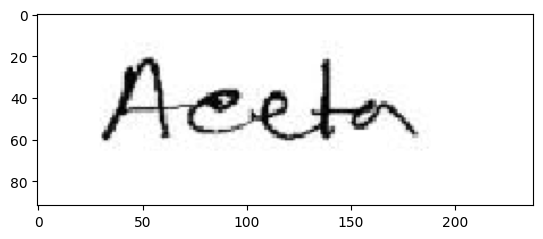

In [4]:
plt.imshow(img,cmap='gray')

# Data Collection

In [5]:
def one_hot_encoded_Y(df):
    return pd.get_dummies(df['MEDICINE_NAME'],dtype=int)

In [6]:
def load_images(image_paths,target_size=(128,32)): # width,height

    imagess=[]

    for path in image_paths:

        img=cv2.imread(path)

        img=cv2.resize(img,target_size)

        img=img.astype('float32')/255.0

        imagess.append(img)

    imagess=np.array(imagess)
    
    imagess=imagess.reshape(imagess.shape[0],32,128,3)

    return imagess

In [7]:
def XY(folder):
    lower=folder.lower()
    
    df=pd.read_csv(f"/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/{folder}/{lower}_labels.csv")
    
    Y=one_hot_encoded_Y(df)
    
    image_folder=f"/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/{folder}/{lower}_words/"
    image_paths=[os.path.join(image_folder,filename) for filename in df['IMAGE']]

    X=load_images(image_paths)

    return X,Y

# Now Model Building Starts , We will build CRNN model

In [8]:
medicine_names=df['MEDICINE_NAME'].unique()
len(medicine_names) # 78 classes

78

In [9]:
x,y=XY("Training")
xval,yval=XY("Validation")
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=12,stratify=y)

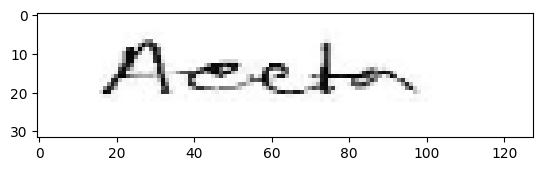

In [10]:
plt.imshow(x[0],cmap='gray')

In [11]:
lambda_reg=0.00001
model=models.Sequential([
    Input(shape=(32, 128, 3)),  

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), 

    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(lambda_reg)),
    MaxPooling2D(pool_size=(2, 2)), 

    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(lambda_reg)),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Flatten the 3D output to 1D for the Dense layers
    Flatten(),

    Dense(1024, activation='relu', kernel_regularizer=l2(lambda_reg)),
    Dropout(0.55), 

    # Output layer
    Dense(len(medicine_names), activation='softmax', kernel_regularizer=l2(lambda_reg))  
])
model.compile(optimizer=Adam(learning_rate=0.0001,beta_1=0.9, beta_2=0.999),loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 128, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 32, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 78)             │        79,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,562,830 (32.66 MB)

 Trainable params: 8,562,830 (32.66 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history=model.fit(xtrain,
                  ytrain,
                  epochs=20,
                  batch_size=32,
                  validation_data=(xval,yval),
                  callbacks=[EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)])
test_loss,test_acc=model.evaluate(xtest,ytest)
print(f"train's test loss : {test_loss}")
print(f"train's test accuracy : {test_acc}")

Epoch 1/20


I0000 00:00:1730969821.427252     155 service.cc:145] XLA service 0x7db5b4004970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730969821.427311     155 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730969821.427315     155 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


24/78 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0171 - loss: 4.4146 

I0000 00:00:1730969826.615536     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.0156 - loss: 4.4032 - val_accuracy: 0.0244 - val_loss: 4.3658
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0215 - loss: 4.3621 - val_accuracy: 0.0154 - val_loss: 4.3090
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0255 - loss: 4.2866 - val_accuracy: 0.0962 - val_loss: 4.0251
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0922 - loss: 3.9561 - val_accuracy: 0.2500 - val_loss: 3.4369
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2300 - loss: 3.4019 - val_accuracy: 0.3218 - val_loss: 3.0468
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2902 - loss: 3.0141 - val_accuracy: 0.4141 - val_loss: 2.7279
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3460 - loss: 2.6773 - val_accuracy: 0.4526 - val_loss: 2.5384
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4288 - loss: 2.3108 - val_accuracy: 0.4795 - val_loss: 2.3150
Ep

# finally testing

In [13]:
xtrain,ytrain=XY("Training")
xtest,ytest=XY("Testing")
xval,yval=XY("Validation")

In [14]:
history=model.fit(xtrain,
                  ytrain,
                  epochs=20,
                  batch_size=32,
                  validation_data=(xval,yval),
                  callbacks=[EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)])
test_loss,test_acc=model.evaluate(xtest,ytest)
print(f"test loss : {test_loss}")
print(f"test accuracy : {test_acc}")

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.8517 - loss: 0.6394 - val_accuracy: 0.6872 - val_loss: 1.4462
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8802 - loss: 0.5352 - val_accuracy: 0.7051 - val_loss: 1.4154
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8988 - loss: 0.4164 - val_accuracy: 0.7051 - val_loss: 1.3619
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9105 - loss: 0.3456 - val_accuracy: 0.7103 - val_loss: 1.3543
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9255 - loss: 0.2998 - val_accuracy: 0.7051 - val_loss: 1.3864
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9392 - loss: 0.2444 - val_accuracy: 0.7256 - val_loss: 1.3746
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9448 - loss: 0.2298 - val_accuracy: 0.7346 - val_loss: 1.3316
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9548 - loss: 0.1837 - val_accuracy: 0.7346 - val_los

# Saving the model

In [15]:
model.save('prescription_classification_model_CNRR.keras')

# Next is OCR Model with charachter level BERT 

In [16]:
def preprocess_image(image_path):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    img = cv2.resize(img, (128, 32))  

    _, img = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return img

In [17]:
def extract_text_with_ocr(image_path):
    preprocessed_image = preprocess_image(image_path)
    
    img = Image.fromarray(preprocessed_image)
    
    extracted_text = pytesseract.image_to_string(img)
    
    return extracted_text

In [18]:
def XYocr(folder):
    lower=folder.lower()
    df=pd.read_csv(f"/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/{folder}/{lower}_labels.csv")
    Y=df['MEDICINE_NAME']

    image_folder=f"/kaggle/input/doctors-handwritten-prescription-bd-dataset/Doctor’s Handwritten Prescription BD dataset/{folder}/{lower}_words/"
    image_paths=[os.path.join(image_folder,filename) for filename in df['IMAGE']]
    X = [extract_text_with_ocr(image_path) for image_path in image_paths]

    return X,Y

In [19]:
xTest,yTest=XYocr("Testing")

In [20]:
count_non_form_feed = sum(1 for value in xTest if value != '\x0c')
count_non_form_feed

458

In [21]:
len(xTest)

780

In [22]:
print(xTest[124])
print(yTest[124])

foeelan

Baclon


In [23]:
xTrain,yTrain=XYocr("Training")
xVal,yVal=XYocr("Validation")

In [24]:
# Define your custom vocabulary (character-level)
vocab_list = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,!?")  
vocab = {char: i for i, char in enumerate(vocab_list, start=1)} 
vocab["[PAD]"] = 0  # Add padding token
vocab["[MASK]"] = len(vocab) + 1  # Mask token
vocab["[CLS]"] = len(vocab) + 2  # CLS token
vocab["[SEP]"] = len(vocab) + 3  # SEP token
vocab["[UNK]"] = len(vocab) + 4  # Unknown token

# Save the vocab to a file
vocab_file = "vocab.txt"
with open(vocab_file, 'w') as f:
    for token in vocab:
        f.write(token + "\n")

# Initialize the tokenizer with the custom vocabulary
tokenizer = BertTokenizerFast(vocab_file=vocab_file)
tokenizer.pad_token = "[PAD]"
tokenizer.mask_token = "[MASK]"
tokenizer.cls_token = "[CLS]"
tokenizer.sep_token = "[SEP]"
tokenizer.unk_token = "[UNK]"

# Save tokenizer to output directory
tokenizer_output_dir = "output_tokenizer"
os.makedirs(tokenizer_output_dir, exist_ok=True)
tokenizer.save_pretrained(tokenizer_output_dir)

# Create a custom Dataset class for loading the data
class CustomDataset(Dataset):
    def __init__(self, x_data, y_data, tokenizer, max_length=128):
        self.x_data = x_data
        self.y_data = y_data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        x = self.x_data[idx]
        y = self.y_data[idx]
        
        inputs = self.tokenizer(x, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        labels = self.tokenizer(y, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        
        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'labels': labels['input_ids'].squeeze()
        }

# Prepare datasets
train_dataset = CustomDataset(xTrain, yTrain, tokenizer)
val_dataset = CustomDataset(xVal, yVal, tokenizer)
test_dataset = CustomDataset(xTest, yTest, tokenizer)

# Set up BERT model configuration
config = BertConfig(
    vocab_size=len(vocab), 
    hidden_size=256,
    num_hidden_layers=6,
    num_attention_heads=8,
    intermediate_size=512,
    max_position_embeddings=512
)

# Initialize the BERT model for masked language modeling
model = BertForMaskedLM(config)

# Set up optimizer and training arguments
optimizer = AdamW(model.parameters(), lr=0.0001)

# Updated TrainingArguments with necessary logging and reporting fixes
training_args = TrainingArguments(
    output_dir="output_model",  # Save model outputs here
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",  # Save model at the end of each epoch
    logging_dir=None,  # No need to log
    logging_steps=1,  # Reduced logging
    logging_first_step=False,  # Do not log first step
    report_to="none",  # Disable WANDB and other reporting
    save_steps=10,
    save_total_limit=1,  # Keep only the most recent model
    load_best_model_at_end=True,  # Load the best model at the end
    disable_tqdm=False,  # Keep tqdm progress bar
    fp16=False  # Disable automatic mixed precision
)

# Custom function to compute accuracy
def compute_accuracy(p):
    preds, labels = p
    preds = torch.tensor(preds)  # Convert to tensor
    preds = torch.argmax(preds, dim=-1)
    return {"accuracy": accuracy_score(labels.flatten(), preds.flatten())}

# Set up Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # Training dataset
    eval_dataset=val_dataset,  # Validation dataset
    optimizers=(optimizer, None),
    compute_metrics=compute_accuracy
)

# Train the model with epoch-wise output
trainer.train()

# Evaluate the model after training on the validation set
final_metrics = trainer.evaluate(val_dataset)
final_accuracy = final_metrics["eval_accuracy"]
final_loss = final_metrics["eval_loss"]

# Evaluate the model on the test set
test_metrics = trainer.evaluate(test_dataset)
test_accuracy = test_metrics["eval_accuracy"]
test_loss = test_metrics["eval_loss"]

# Display epoch-wise output and final test results
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

BertForMaskedLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.048600,0.008098,0.999089
2,0.018000,0.005923,0.999099
3,0.001800,0.005569,0.999099


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Final Test Accuracy: 0.9991
Final Test Loss: 0.0056


# AND , We have achieved 99.91% accuracy on Test

In [25]:
# I still am a learner in ML so if any improvement could be done, do tell
# any mistake made, do tell ,comment

# :) Do comment for anything done wrong ;)